<a href="https://colab.research.google.com/github/branka2004/preporuka_proizvoda_u_elektronskoj_trgovini/blob/main/preporuka_proizvoda_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Primena deep learninga za preporuku proizvoda u elektronskoj trgovini pomoću autoenkodera

## Projekat iz predmeta: Duboko učenje i neuronske mreže

### Autori:
- Nikola Ilic 2022/0190
- Branka Bakovic 2022/0295

# Opis projekta

Cilj ovog projekta je implementacija sistema za preporuku proizvoda korišćenjem tehnika dubokog učenja i autoenkodera.

Model će biti treniran nad Amazon Reviews skupom podataka kako bi naučio latentne reprezentacije korisničkih preferencija i generisao personalizovane preporuke proizvoda.

U okviru projekta biće analizirane različite arhitekture autoenkodera, performanse modela i kvalitet preporuka korišćenjem standardnih evaluacionih metrika.

# Neophodni importi

In [14]:
import io
import os
import random

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

RAND_STATE = 42

print("PyTorch verzija:", torch.__version__)
print("Da li je GPU dostupan:", torch.cuda.is_available())

PyTorch verzija: 2.11.0+cu128
Da li je GPU dostupan: True


In [15]:
df = pd.read_csv('/content/Reviews.csv')

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


# Analiza skupa podataka

In [17]:
print("Broj redova i kolona:")
print(df.shape)

print("\nNazivi kolona:")
print(df.columns)

print("\nBroj jedinstvenih korisnika:")
print(df['UserId'].nunique())

print("\nBroj jedinstvenih proizvoda:")
print(df['ProductId'].nunique())

print("Nedostajuće vrednosti:\n")
print(df.isnull().sum())



Broj redova i kolona:
(568454, 10)

Nazivi kolona:
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

Broj jedinstvenih korisnika:
256059

Broj jedinstvenih proizvoda:
74258
Nedostajuće vrednosti:

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


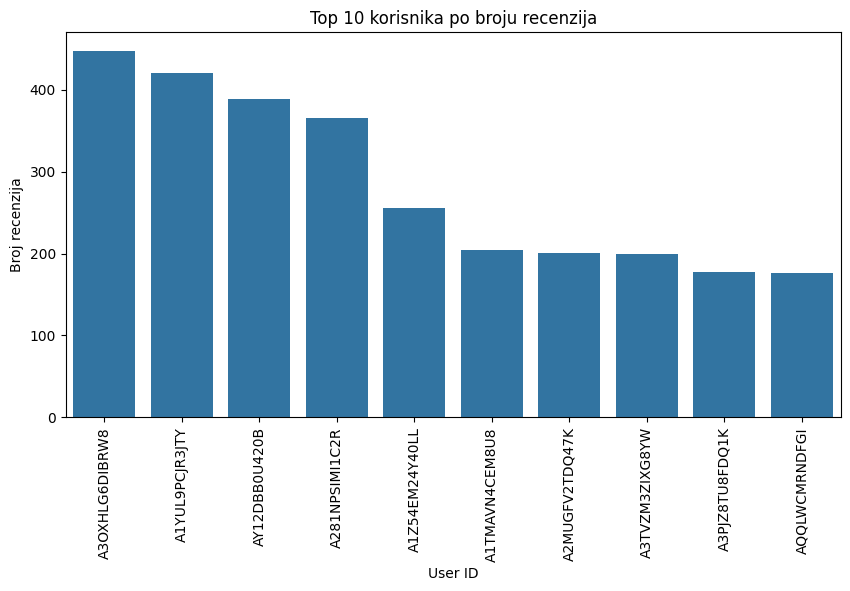

In [18]:
top_users = df['UserId'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_users.index, y=top_users.values)

plt.title("Top 10 korisnika po broju recenzija")
plt.xlabel("User ID")
plt.ylabel("Broj recenzija")

plt.xticks(rotation=90)

plt.show()

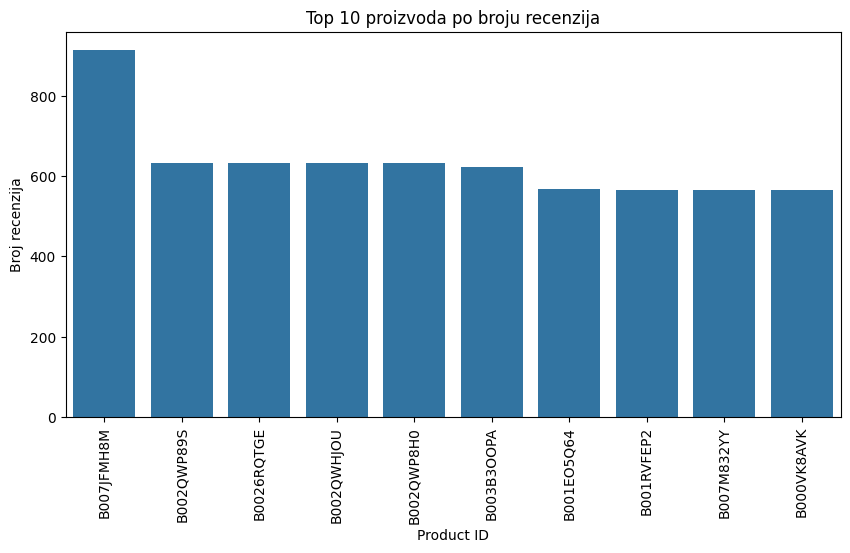

In [19]:
top_products = df['ProductId'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_products.index, y=top_products.values)

plt.title("Top 10 proizvoda po broju recenzija")
plt.xlabel("Product ID")
plt.ylabel("Broj recenzija")

plt.xticks(rotation=90)

plt.show()

Na osnovu inicijalne analize skupa podataka može se uočiti da dataset sadrži veliki broj korisničkih recenzija i ocena proizvoda iz elektronske trgovine.

Skup podataka sadrži informacije o korisnicima, proizvodima, numeričkim ocenama, tekstualnim komentarima i vremenu ostavljanja recenzije.


# Preprocesiranje podataka

U sistemima za preporuku proizvoda, podaci se najčešće transformišu u tzv. user-item matricu.

Redovi matrice predstavljaju korisnike, kolone proizvode, dok vrednosti unutar matrice predstavljaju ocene koje su korisnici dodelili proizvodima.

S obzirom na veličinu originalnog skupa podataka i veliku sparsnost matrice, biće izvršena filtracija korisnika i proizvoda sa veoma malim brojem interakcija kako bi se omogućilo efikasnije treniranje modela.

In [21]:
# Zadržavamo samo korisnike sa minimum 20 recenzija
active_users = user_counts[user_counts >= 20].index

# Zadržavamo samo proizvode sa minimum 20 recenzija
popular_products = product_counts[product_counts >= 20].index

# Filtriran dataset
filtered_df = df[
    (df['UserId'].isin(active_users)) &
    (df['ProductId'].isin(popular_products))
]

print("Originalna dimenzija:", df.shape)
print("Filtrirana dimenzija:", filtered_df.shape)

Originalna dimenzija: (568454, 10)
Filtrirana dimenzija: (47380, 10)


Nakon inicijalne analize skupa podataka izvršena je filtracija korisnika i proizvoda sa veoma malim brojem interakcija.

U recommendation sistemima veliki broj korisnika ostavlja veoma mali broj recenzija, dok pojedini proizvodi imaju svega nekoliko ocena. Takvi podaci otežavaju proces učenja modela i mogu negativno uticati na kvalitet preporuka.

Iz tog razloga zadržani su samo korisnici koji imaju najmanje 20 recenzija, kao i proizvodi sa najmanje 20 ocena. Ovim postupkom smanjena je dimenzionalnost problema i povećan kvalitet podataka koji se koriste za treniranje modela.

Nakon filtracije broj interakcija značajno je smanjen, čime je omogućeno efikasnije treniranje neuronske mreže i stabilnija konstrukcija user-item matrice.


# Kreiranje user-item matrice

Nakon filtracije podataka, kreira se user-item matrica koja predstavlja osnovu sistema za preporuku proizvoda.

Svaki red matrice predstavlja jednog korisnika, dok svaka kolona predstavlja jedan proizvod. Vrednosti u matrici predstavljaju ocene koje su korisnici dodelili proizvodima.

Nedostajuće vrednosti biće popunjene nulama, što označava da korisnik nije ocenio određeni proizvod.

In [22]:
# Kreiranje user-item matrice

user_item_matrix = filtered_df.pivot_table(
    index='UserId',
    columns='ProductId',
    values='Score'
)

# Popunjavanje nedostajućih vrednosti nulama
user_item_matrix = user_item_matrix.fillna(0)

print("Dimenzije user-item matrice:")
print(user_item_matrix.shape)

user_item_matrix.head()

Dimenzije user-item matrice:
(1879, 4308)


ProductId,7310172001,7310172101,B00004CI84,B00004CXX9,B00004RAMY,B00004RBDU,B00004RBDZ,B00004RYGX,B00004S1C6,B000084DWM,...,B009AFJ3I6,B009AFJ548,B009B87SAC,B009E7YC54,B009GHI5Q4,B009HXB2JO,B009M2LPHO,B009M2LRTA,B009M2LUEW,B009RB4GO4
UserId,,,,,,,,,,,,,,,,,,,,,
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A101P2KHWCU0G6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
A1051DBTLWP5A2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A106ZCP7RSXMRU,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1080SE9X3ECK0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


User-item matrica predstavlja centralnu komponentu sistema za preporuku proizvoda.

Redovi matrice predstavljaju korisnike, kolone predstavljaju proizvode, dok vrednosti unutar matrice predstavljaju ocene koje su korisnici dodelili proizvodima.

U slučajevima kada korisnik nije ocenio određeni proizvod, vrednost se popunjava nulom. Ovakva reprezentacija omogućava neuronskoj mreži da analizira obrasce korisničkih preferencija i pronalazi skrivene relacije između proizvoda i korisnika.

Dobijena matrica predstavlja ulaz u autoencoder model koji će pokušati da rekonstruiše korisničke preference i predvidi potencijalno interesantne proizvode za svakog korisnika.


In [23]:
# Sparsity matrice

matrix_values = user_item_matrix.values

sparsity = 1.0 - (
    np.count_nonzero(matrix_values) /
    float(matrix_values.size)
)

print(f"Sparsity matrice: {sparsity:.4f}")

Sparsity matrice: 0.9947


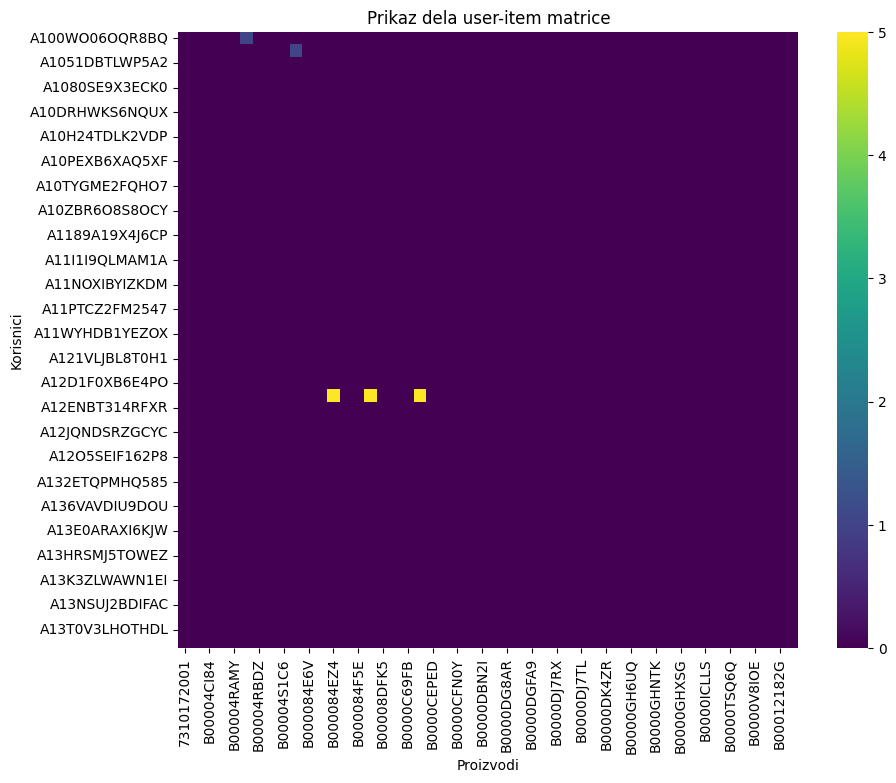

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    user_item_matrix.iloc[:50, :50],
    cmap='viridis'
)

plt.title("Prikaz dela user-item matrice")

plt.xlabel("Proizvodi")
plt.ylabel("Korisnici")

plt.show()

Analiza sparsnosti user-item matrice pokazuje da veliki broj elemenata matrice sadrži nulte vrednosti, odnosno nedostajuće interakcije između korisnika i proizvoda.

Dobijena vrednost sparsnosti od približno 99% ukazuje da većina korisnika ocenjuje samo mali broj proizvoda, što predstavlja tipičan problem recommendation sistema u realnim uslovima.

Visoka sparsnost otežava proces predviđanja korisničkih preferencija jer model raspolaže ograničenim brojem poznatih interakcija. Upravo zbog toga autoenkoderi predstavljaju pogodno rešenje, budući da mogu naučiti latentne reprezentacije korisnika i proizvoda čak i u uslovima veoma retkih podataka.

Na osnovu kreirane user-item matrice može se uočiti izražena sparsnost podataka, što predstavlja tipičan problem u sistemima za preporuku proizvoda.

Veliki broj nedostajućih interakcija između korisnika i proizvoda otežava proces učenja modela, zbog čega su autoenkoderi pogodni za pronalaženje latentnih reprezentacija i rekonstrukciju korisničkih preferencija.